In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv(r'C:\Users\user\Desktop\Skilfactory\data1\snsdata.csv')
df.head()

,gradyear,gender,age,friends,basketball,football,soccer,softball,volleyball,swimming,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,2006,M,18.982,7,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2006,F,18.801,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
2,2006,M,18.335,69,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,2006,F,18.875,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2006,NaN,18.995,10,0,0,0,0,0,0,...,0,0,2,0,0,0,0,0,1,1


In [3]:
df.drop(['gradyear', 'gender', 'age', 'friends'], axis=1, inplace=True)

In [4]:
df_old = df.copy()

In [5]:
df.shape

(30000, 36)

In [6]:
col = df.columns

In [7]:
r_scaler = StandardScaler()
df = r_scaler.fit_transform(df)

In [8]:
df[0][0]

-0.3322172643985876

In [9]:
from sklearn.cluster import KMeans
Kmeans = KMeans(n_clusters=9, random_state=42)
Kmeans.fit(df)
Kmeans.inertia_

856276.6962467819

In [10]:
pd.DataFrame(Kmeans.labels_).value_counts()

0
1    19599
2     4284
0     2201
4      941
3      902
5      851
8      754
7      467
6        1
Name: count, dtype: int64

In [11]:
def get_inertia(cluster_num, X):
    k_means =  KMeans(n_clusters=cluster_num, random_state=42)
    k_means.fit(X)
    inertia = k_means.inertia_
    return inertia

<Axes: >

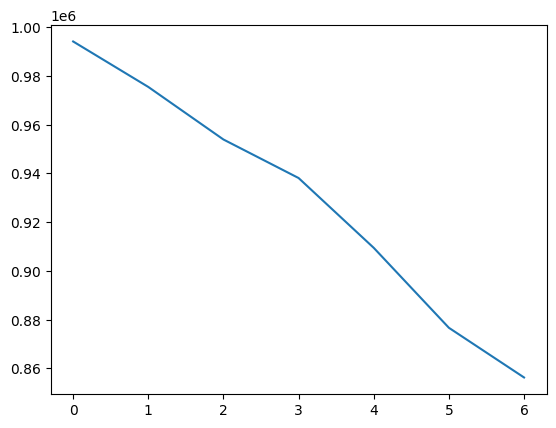

In [12]:
l = []
for i in range(3, 10):
    inert = get_inertia(i, df)
    l.append(inert)
    
import seaborn as sns
sns.lineplot(l)

In [13]:
from sklearn.metrics import silhouette_score

In [14]:
# def get_silhouette(cluster_num, X):
#     k_means =  KMeans(n_clusters=cluster_num, random_state=42)
#     k_means.fit(X)
# # подсчитаем метрику силуэта, передав данные и то, к каким кластерам относятся объекты
#     silhouette = silhouette_score(X, k_means.labels_)
#     return silhouette

# silhouette = []
# for clust_num in range(3, 10):
#     silhouette.append(get_silhouette(clust_num, df))

In [15]:
# sns.lineplot(silhouette)

In [16]:
km = KMeans(n_clusters=3)
km.fit(df)
clustr = km.fit_predict(df)

In [17]:
df_new = pd.DataFrame(df_old, columns=col)
df_new['cluster'] = clustr

In [18]:
gr = df_new.groupby('cluster').mean()
grt = gr.T.rank()
grt['all'] = grt[0] + grt[1] + grt[2]
grt.sort_values('all',ascending=False).head(10)

cluster,0,1,2,all
music,36.0,36.0,34.0,106.0
hair,32.0,31.0,36.0,99.0
god,35.0,33.0,30.0,98.0
dance,34.0,35.0,28.0,97.0
shopping,31.0,34.0,21.0,86.0
band,33.0,26.0,27.0,86.0
cute,30.0,32.0,23.0,85.0
rock,29.0,22.0,31.0,82.0
mall,24.0,29.0,22.0,75.0
basketball,27.0,28.0,20.0,75.0


In [19]:
top_list = []
for label, group in df_new.groupby('cluster'):
    means = group.iloc[:,:-1].mean().sort_values(ascending=False)
    top_5 = set(means.head(10).index)
    top_list.append(top_5)

set.intersection(*top_list)

{'dance', 'god', 'hair', 'music'}

In [20]:
from sklearn.mixture import GaussianMixture
GM = GaussianMixture(n_components=3, random_state=42)
l = GM.fit_predict(df)
pd.DataFrame(l).value_counts()

0
0    20670
2     6456
1     2874
Name: count, dtype: int64

In [21]:
np.unique(l, return_counts=True)
a = np.where(l == 2)
df_old.iloc[a]

,basketball,football,soccer,softball,volleyball,swimming,cheerleading,baseball,tennis,sports,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
1,0,1,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
19,0,0,0,0,0,0,1,0,0,0,...,0,1,2,0,1,1,0,0,0,0
20,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,2,0,0,0,0
21,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29968,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
29984,2,0,4,0,0,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
29987,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0
29988,0,0,0,0,0,0,3,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
df = pd.read_csv(r'C:\Users\user\Desktop\Skilfactory\data1\CC GENERAL.csv')

In [23]:
df

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


In [24]:
df.isna().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [25]:
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].mean())
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].mean())

In [26]:
df['MINIMUM_PAYMENTS'].mean()

864.2065423050827

In [27]:
df

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,864.206542,0.000000,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


In [28]:
df.drop('CUST_ID', axis=1, inplace=True)

In [29]:
r_scaler = StandardScaler()
df_n = df.copy()
X = r_scaler.fit_transform(df)

In [30]:
X[0][0]

-0.7319893664465486

In [31]:
def get_silhouette(cluster_num, X):
    k_means =  KMeans(n_clusters=cluster_num, random_state=42, init='random')
    k_means.fit(X)
    silhouette = silhouette_score(X, k_means.labels_)
    return silhouette

silhouette = []
for clust_num in range(2, 10):
    silhouette.append(get_silhouette(clust_num, X))

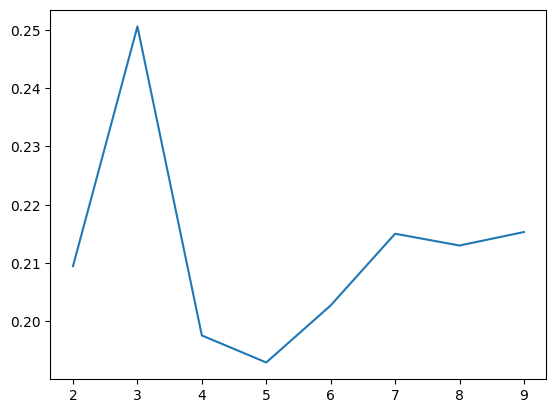

In [32]:
sns.lineplot(y=silhouette, x=range(2, 10));

In [33]:
km = KMeans(n_clusters=3, random_state=42, init='random')
label = km.fit_predict(X)
print(pd.Series(label).value_counts())

2    6119
1    1596
0    1235
Name: count, dtype: int64


In [34]:
from sklearn.cluster import DBSCAN
DB = DBSCAN()
label = DB.fit_predict(X)
print(pd.Series(label).nunique())

39


In [35]:
# silhouette = {}
# def get_silhouette_DB(eps, min_samples, X):
#     DB =  DBSCAN(eps=eps, min_samples=min_samples)
#     DB.fit_predict(X)
#     silhouette = silhouette_score(X, DB.labels_)
#     return silhouette

# for eps in np.arange(0.1,3,0.2):
#     for min_sampl in range(1, 20, 4):
#         silhouette[('eps', eps), ('min_samples', min_sampl)] = get_silhouette_DB(eps, min_sampl, X)
        


In [36]:
from sklearn.cluster import AgglomerativeClustering

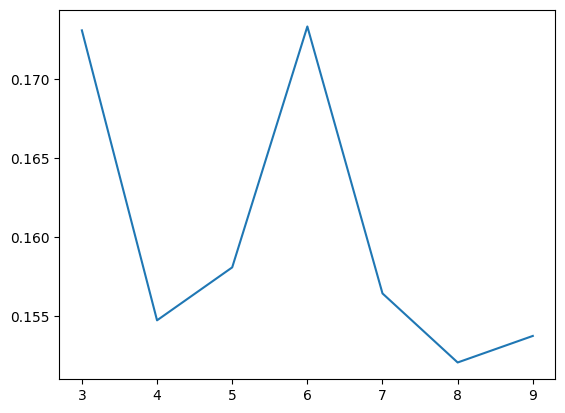

In [37]:
def get_silhouette(cluster_num, X):
    ag =  AgglomerativeClustering(n_clusters=cluster_num)
    ag.fit(X)
    silhouette = silhouette_score(X, ag.labels_)
    return silhouette

silhouette = []
for clust_num in range(3, 10):
    silhouette.append(get_silhouette(clust_num, X))
    
sns.lineplot(y=silhouette, x=range(3, 10));

In [38]:
ag = AgglomerativeClustering(n_clusters=6)
lab = ag.fit_predict(X)
print(pd.Series(lab).value_counts())

0    3946
1    2931
2     864
5     722
3     464
4      23
Name: count, dtype: int64


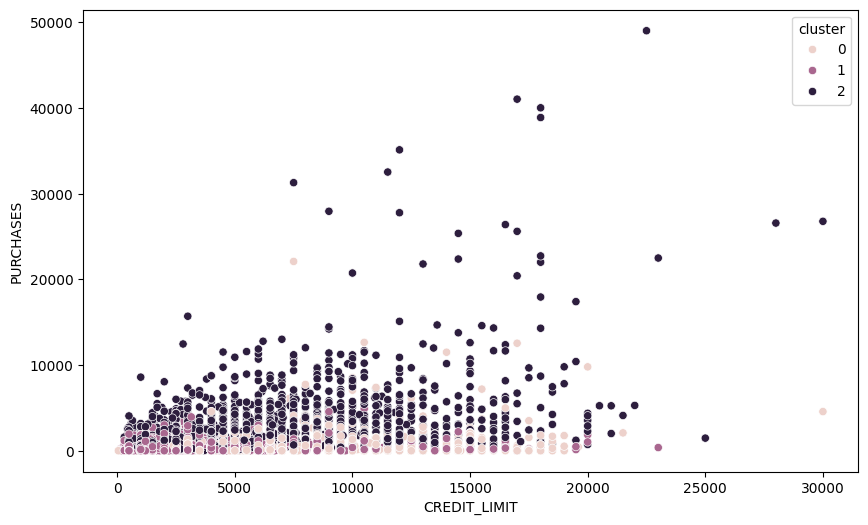

In [39]:
import matplotlib.pyplot as plt
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)
df['cluster'] = kmeans.labels_
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='CREDIT_LIMIT', y='PURCHASES', hue='cluster')
plt.show()

In [40]:
from sklearn.metrics import calinski_harabasz_score
#определяем алгоритм кластеризации
km = KMeans(n_clusters=3, random_state=42)
#обучаем его на наших данных
km.fit_predict(X)
#вычисляем значение коэффициента Калински — Харабаса
score = calinski_harabasz_score(X, km.labels_)
score

1570.8049380876023

In [41]:
from sklearn.metrics import davies_bouldin_score
#определяем алгоритм кластеризации
km = KMeans(n_clusters=3, random_state=42)
#обучаем его на наших данных
km.fit_predict(X)
#вычисляем значение коэффициента Дэвиса — Болдина
score = davies_bouldin_score(X, km.labels_)
score

1.6595405785050528

In [42]:
train = np.loadtxt(r'C:\Users\user\Desktop\Skilfactory\data1\train.txt')
test = np.loadtxt(r'C:\Users\user\Desktop\Skilfactory\data1\test.txt')
train_label = np.loadtxt(r'C:\Users\user\Desktop\Skilfactory\data1\train_labels.txt')
test_label = np.loadtxt(r'C:\Users\user\Desktop\Skilfactory\data1\test_labels.txt')
X = np.concatenate((train, test))
y = np.concatenate((train_label, test_label))

In [43]:
X.shape

(10299, 561)

In [44]:
pd.Series(y).value_counts()

6.0    1944
5.0    1906
4.0    1777
1.0    1722
2.0    1544
3.0    1406
Name: count, dtype: int64

In [45]:
X_norm = r_scaler.fit_transform(X)
X_norm[0][0]

0.2105338541767611

<Axes: >

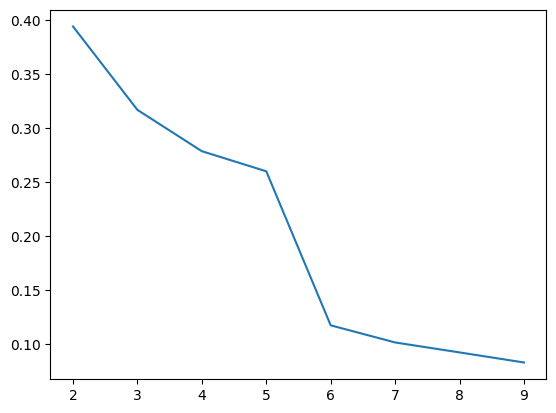

In [46]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.cluster import KMeans
def silhouette_sc(cluster_num, X):
    kmeans = KMeans(n_clusters=cluster_num, init='k-means++', random_state=42)
    kmeans.fit_predict(X)
    silhot = silhouette_score(X, kmeans.labels_)
    return silhot

silhouette = []
for i in range(2, 10):
    sil = silhouette_sc(i, X_norm)
    silhouette.append(sil)
    
sns.lineplot(y=silhouette, x=np.arange(2, 10))
    

[1.0707441822385657,
 1.7838205288134947,
 2.0464376750898374,
 2.2664850032126433,
 2.52599900702495,
 2.65028581558819,
 2.619035633846788,
 2.7593862241965237]

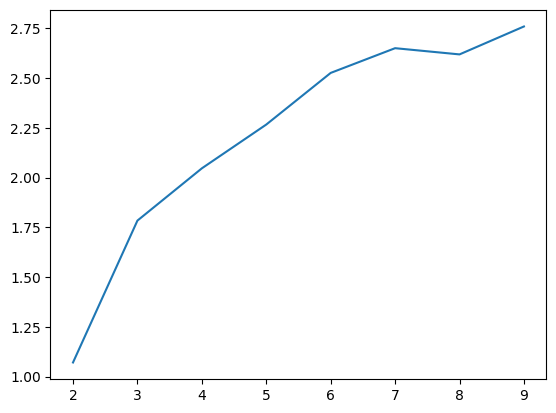

In [47]:
def silhouette_sc(cluster_num, X):
    kmeans = KMeans(n_clusters=cluster_num, init='k-means++', random_state=42)
    kmeans.fit_predict(X)
    silhot = davies_bouldin_score(X, kmeans.labels_)
    return silhot

silhouette = []
for i in range(2, 10):
    sil = silhouette_sc(i, X_norm)
    silhouette.append(sil)
    
sns.lineplot(y=silhouette, x=np.arange(2, 10))
silhouette

[7880.813903657111,
 5034.470017849821,
 3668.0173727083115,
 2845.838894164787,
 2504.6858590869924,
 2171.068983512932,
 1890.8900519769945,
 1685.013483142379]

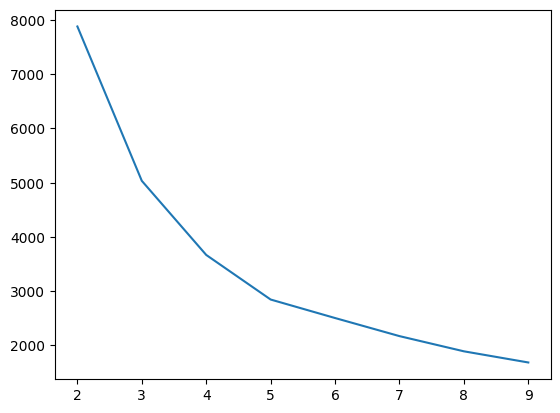

In [48]:
def silhouette_sc(cluster_num, X):
    kmeans = KMeans(n_clusters=cluster_num, init='k-means++', random_state=42)
    kmeans.fit_predict(X)
    silhot = calinski_harabasz_score(X, kmeans.labels_)
    return silhot

silhouette = []
for i in range(2, 10):
    sil = silhouette_sc(i, X_norm)
    silhouette.append(sil)
    
sns.lineplot(y=silhouette, x=np.arange(2, 10))
silhouette

In [49]:
from sklearn.metrics import homogeneity_completeness_v_measure
kmeans = KMeans(n_clusters=6, random_state=42, init='random')
kmeans.fit(X_norm)
print(homogeneity_completeness_v_measure(y, kmeans.labels_))

(0.5406994702303469, 0.5792825031740629, 0.559326399920236)


In [50]:
from sklearn.metrics import adjusted_rand_score
print(adjusted_rand_score(y, kmeans.labels_))

0.41962042580459846


In [51]:
#создаём таблицу сопряжённости
ct = pd.crosstab(y, kmeans.labels_)
#определяем название активностей
ct.index = ['ходьба', 'подъём', 
            'спуск', 'сидение', 'стояние', 'лежание']
ct.columns = list(range(1,7))

In [52]:
ct

,1,2,3,4,5,6
ходьба,741,897,0,0,84,0
подъём,297,1236,2,0,9,0
спуск,882,310,0,0,214,0
сидение,0,1,447,91,0,1238
стояние,0,0,560,0,0,1346
лежание,0,5,329,1556,0,54


In [53]:
#создаём таблицу сопряжённости
kmeans = KMeans(init='k-means++', n_clusters=2, random_state=42)
kmeans.fit(X_norm)
ct = pd.crosstab(y, kmeans.labels_)
#определяем название активностей
ct.index = ['ходьба', 'подъём', 
            'спуск', 'сидение', 'стояние', 'лежание']
ct.columns = list(range(1,3))
ct

,1,2
ходьба,0,1722
подъём,8,1536
спуск,0,1406
сидение,1774,3
стояние,1906,0
лежание,1932,12


In [54]:
print(homogeneity_completeness_v_measure(y, kmeans.labels_))

(0.37797082246896085, 0.9795305596996312, 0.5454638590374131)


In [55]:
AG = AgglomerativeClustering(n_clusters=2)
AG.fit(X_norm)
print(homogeneity_completeness_v_measure(y, AG.labels_))

(0.38579907418430925, 0.9999999999999993, 0.5567893374606173)


In [56]:
import numpy as np
import pandas as pd
A = np.matrix([[1,2,3,4],
               [5,5,6,7],
               [1,4,2,3],
               [5,3,2,1],
               [8,1,2,2]])

df = pd.DataFrame(A,columns  = ['x1','x2','x3','x4'])
df_std  = (df - df.mean()) / (df.std())

In [57]:
cov_mat = np.cov(df_std.T)
cov_mat

array([[ 1.        , -0.31622777,  0.04811252, -0.18098843],
       [-0.31622777,  1.        ,  0.63900965,  0.61812254],
       [ 0.04811252,  0.63900965,  1.        ,  0.94044349],
       [-0.18098843,  0.61812254,  0.94044349,  1.        ]])

In [58]:
eigen_val, eigen_vectors = np.linalg.eig(cov_mat)

In [59]:
#импортируем нужный алгоритм

from sklearn.decomposition import PCA
#определяем метод главных компонент с двумя компонентами
pca = PCA(n_components=2)
#обучаем алгоритм на наших данных
principalComponents = pca.fit_transform(df_std)

In [60]:
A = np.matrix([[3, 4, 1],
               [1, 6, 2]])

df = pd.DataFrame(A,columns  = ['x1','x2', 'x3'])
df_std  = (df - df.mean()) / (df.std())
r = np.cov(df_std.T)

In [61]:
sum(r)

array([-1.,  1.,  1.])

In [62]:
A = np.matrix([[8,7,2,9],
               [1,3,6,3],
               [7,2,0,3],
               [10,3,1,1],
               [8,1,3,4]])

df = pd.DataFrame(A,columns  = ['x1','x2', 'x3', 'x4'])
df_std  = (df - df.mean()) / (df.std())

In [63]:
pca = PCA(n_components=0.9)
#обучаем алгоритм на наших данных
principalComponents = pca.fit_transform(df_std)
principalComponents

array([[ 1.61145254,  1.76368007, -0.01320928],
       [-2.08441051,  1.01724955,  0.24417084],
       [ 0.29568142, -0.95946326,  0.05272576],
       [ 0.50390826, -1.24373821,  0.50808763],
       [-0.3266317 , -0.57772816, -0.79177495]])

In [64]:
from sklearn.decomposition import TruncatedSVD
# создаём объект класса TruncatedSVD
# n_components — размерность нового пространства, n_iter — количество итераций
svd = TruncatedSVD(n_components=5, n_iter=7, random_state=42)
# обучаем модель на данных X
svd.fit(X)
# применяем уменьшение размерности к матрице X
transformed = svd.transform(X)

In [66]:
# импортируем класс TSNE из модуля manifold библиотеки sklearn
from sklearn.manifold import TSNE
# создаём объект класса TSNE
# n_components — размерность нового пространства
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
# обучаем модель на данных X и применяем к матрице X уменьшение размерности
tsne.fit_transform(X)

array([[-39.446686,  70.071014],
       [-42.588387,  11.239199],
       [-41.232994,  45.553326],
       ...,
       [ 31.309916,  32.516277],
       [ 31.097141,  32.585926],
       [ 31.079224,  32.421078]], dtype=float32)

In [67]:
df = pd.read_csv(r'C:\Users\user\Desktop\Skilfactory\data1\Country-data.csv')
df

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [68]:
df['life_expec'].max()

82.8

In [69]:
df_copy = df.copy()
df.drop('country', axis=1, inplace=True)

In [70]:
df = r_scaler.fit_transform(df)

In [72]:
df[0][0]

1.2915323778422956

<Axes: >

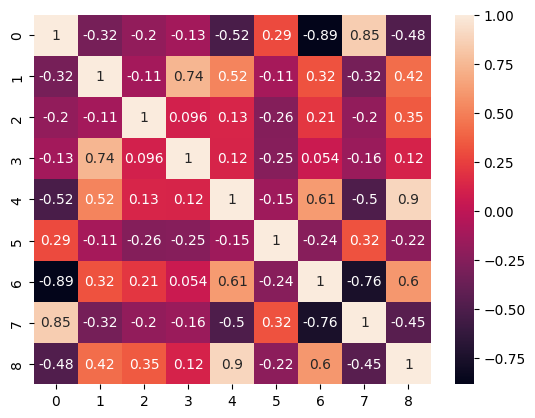

In [76]:
sns.heatmap((pd.DataFrame(df)).corr(), annot=True)

In [85]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.9)
l = pca.fit_transform(df)
l.shape

(167, 5)

In [87]:
data = pca.explained_variance_ratio_
data[0]

0.4595173978609589

<Axes: >

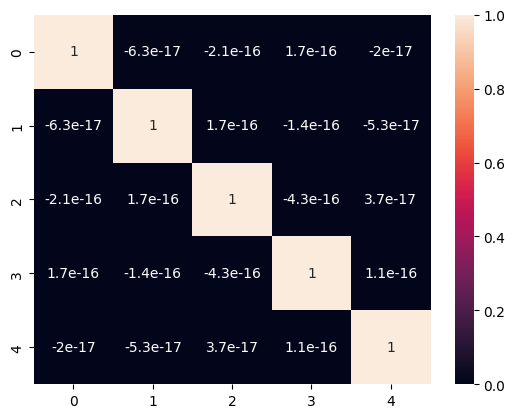

In [89]:
sns.heatmap(pd.DataFrame(l).corr(), annot=True)

In [94]:
def get_silhouette(cluster_num, X):
    k_means =  KMeans(n_clusters=cluster_num, random_state=1, init='k-means++')
    k_means.fit(X)
    silhouette = silhouette_score(X, k_means.labels_)
    return silhouette


<Axes: >

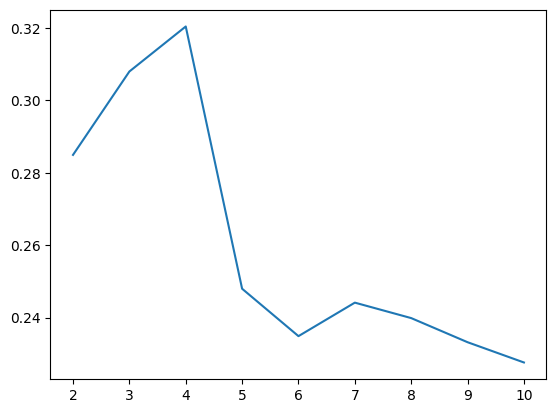

In [96]:
silhoette = []
for i in range(2, 11):
    sil = get_silhouette(i, l)
    silhoette.append(sil)
sns.lineplot(y = silhoette, x = np.arange(2, 11))
    


In [102]:
k_means =  KMeans(n_clusters=4, random_state=1, init='k-means++')
k_means.fit_transform(l)
label = k_means.labels_
df_copy['label'] = pd.Series(label)

In [106]:
df_copy.sort_values('child_mort', ascending=False)
df_copy[df_copy['label'] == 0].sort_values('life_expec')

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,label
66,Haiti,208.0,15.300,6.91,64.7000,1500,5.450,32.1,3.33,662,0
87,Lesotho,99.7,39.400,11.10,101.0000,2380,4.150,46.5,3.30,1170,0
31,Central African Republic,149.0,11.800,3.98,26.5000,888,2.010,47.5,5.21,446,0
166,Zambia,83.1,37.000,5.89,30.9000,3280,14.000,52.0,5.40,1460,0
94,Malawi,90.5,22.800,6.59,34.9000,1030,12.100,53.1,5.31,459,0
137,South Africa,53.7,28.600,8.94,27.4000,12000,6.350,54.3,2.59,7280,0
106,Mozambique,101.0,31.500,5.21,46.2000,918,7.640,54.5,5.56,419,0
132,Sierra Leone,160.0,16.800,13.10,34.5000,1220,17.200,55.0,5.20,399,0
64,Guinea-Bissau,114.0,14.900,8.50,35.2000,1390,2.970,55.6,5.05,547,0
0,Afghanistan,90.2,10.000,7.58,44.9000,1610,9.440,56.2,5.82,553,0
